# EDA
## Tải tất cả thư viện cần thiết và xử lý dataframe

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as pit

# Đọc file
df = pd.read_csv('../data/used_cars.csv')
df


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"
...,...,...,...,...,...,...,...,...,...,...,...,...
4004,Bentley,Continental GT Speed,2023,714 mi.,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,Yes,"$349,950"
4005,Audi,S4 3.0T Premium Plus,2022,"10,900 mi.",Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,"$53,900"
4006,Porsche,Taycan,2022,"2,116 mi.",NaN,Electric,Automatic,Black,Black,None reported,NaN,"$90,998"
4007,Ford,F-150 Raptor,2020,"33,000 mi.",Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,Yes,"$62,999"


## Xử lý các ký tự cần thiết

In [112]:
# Xử lý giá tiền của xe từ chuỗi thành số

df['price'] = (
    df['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(int)
)

# Xử lý số dặm xe đã đi

df['milage'] = (
    df['milage']
    .str.replace(',', '', regex=False)
    .str.replace('mi.', '', regex=False)
    .astype(int)
)

df['milage']

# Thêm cột "age" để biểu diễn số tuổi của chiếc xe

df['age'] = 2026 - df['model_year']

# Thêm cột horsepower để biểu diễn số mã lực dựa trên cột "engine" của chiếc xe

df['horsepower'] = df['engine'].str.extract(
    r'(\d+\.?\d*)\s*HP'
).astype(float)

# Trích xuất số từ cột engine
def extract_hp(text):
    m = re.search(r'([\d.]+)\s*HP', str(text))
    return float(m.group(1)) if m else np.nan

def extract_liter(text):
    m = re.search(r'([\d.]+)\s*L\b', str(text))
    return float(m.group(1)) if m else np.nan

def extract_cylinders(text):
    m = re.search(r'(\d+)\s*Cylinder', str(text))
    return int(m.group(1)) if m else np.nan

df['engine_hp'] = df['engine'].apply(extract_hp)
df['engine_liter'] = df['engine'].apply(extract_liter)
df['engine_cylinder'] = df['engine'].apply(extract_cylinders)

df ['engine_hp']

# Nếu horsepower gốc đã có sẵn, dùng để lấp chỗ thiếu trong engine_hp
df['engine_hp'] = df['engine_hp'].fillna(df['horsepower'])

for col in ['engine_hp', 'engine_liter', 'engine_cylinder']:
    df[col] = df[col].fillna(df[col].median())

df = df.drop(columns=['engine', 'horsepower'])

# Xóa cột not supported trong dữ liệu
fuel_counts = df['fuel_type'].value_counts()
# fuel_counts = fuel_counts.drop(5)

# fuel_counts
df

,brand,model,model_year,milage,fuel_type,transmission,ext_col,int_col,accident,clean_title,price,age,engine_hp,engine_liter,engine_cylinder
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300,13,300.0,3.7,6.0
1,Hyundai,Palisade SEL,2021,34742,Gasoline,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005,5,310.0,3.8,6.0
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,Automatic,Blue,Black,None reported,NaN,54598,4,310.0,3.5,6.0
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,7-Speed A/T,Black,Black,None reported,Yes,15500,11,354.0,3.5,6.0
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999,5,310.0,2.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4004,Bentley,Continental GT Speed,2023,714,Gasoline,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,Yes,349950,3,310.0,6.0,6.0
4005,Audi,S4 3.0T Premium Plus,2022,10900,Gasoline,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,53900,4,349.0,3.0,6.0
4006,Porsche,Taycan,2022,2116,NaN,Automatic,Black,Black,None reported,NaN,90998,4,310.0,3.5,6.0
4007,Ford,F-150 Raptor,2020,33000,Gasoline,A/T,Blue,Black,None reported,Yes,62999,6,450.0,3.5,6.0


## Xử lý các giá trị null

In [113]:
# Số lượng giá trị null

df.isnull().sum()

brand                0
model                0
model_year           0
milage               0
fuel_type          170
transmission         0
ext_col              0
int_col              0
accident           113
clean_title        596
price                0
age                  0
engine_hp            0
engine_liter         0
engine_cylinder      0
dtype: int64

In [114]:
# Xóa các hàng có các giá trị là null hoặc không có giá trị

df = df.dropna(axis=0)

In [115]:
# Kiểm tra lại các giá trị null hoặc không có giá trị

df.isnull().sum()

brand              0
model              0
model_year         0
milage             0
fuel_type          0
transmission       0
ext_col            0
int_col            0
accident           0
clean_title        0
price              0
age                0
engine_hp          0
engine_liter       0
engine_cylinder    0
dtype: int64

In [116]:
# Hiển thị các giá trị cơ bản trong dataframe
df.describe()

,model_year,milage,price,age,engine_hp,engine_liter,engine_cylinder
count,3269.000000,3269.000000,3.269000e+03,3269.000000,3269.000000,3269.000000,3269.000000
mean,2014.601407,72126.951973,4.124113e+04,11.398593,324.373509,3.725665,6.229734
std,6.152181,53387.413623,8.304604e+04,6.152181,107.994165,1.413630,1.593330
min,1974.000000,100.000000,2.000000e+03,2.000000,70.000000,1.000000,3.000000
25%,2011.000000,30450.000000,1.550000e+04,7.000000,252.000000,2.500000,6.000000
50%,2016.000000,62930.000000,2.800000e+04,10.000000,310.000000,3.500000,6.000000
75%,2019.000000,102750.000000,4.650000e+04,15.000000,385.000000,4.700000,8.000000
max,2024.000000,405000.000000,2.954083e+06,52.000000,797.000000,8.400000,12.000000


In [117]:
df.head()

,brand,model,model_year,milage,fuel_type,transmission,ext_col,int_col,accident,clean_title,price,age,engine_hp,engine_liter,engine_cylinder
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300,13,300.0,3.7,6.0
1,Hyundai,Palisade SEL,2021,34742,Gasoline,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005,5,310.0,3.8,6.0
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,7-Speed A/T,Black,Black,None reported,Yes,15500,11,354.0,3.5,6.0
6,Audi,S3 2.0T Premium Plus,2017,84000,Gasoline,6-Speed A/T,Blue,Black,None reported,Yes,31000,9,292.0,2.0,4.0
7,BMW,740 iL,2001,242000,Gasoline,A/T,Green,Green,None reported,Yes,7300,25,282.0,4.4,8.0


In [118]:
# Phân loại các dạng hộp số

def clean_transmission(transmission):
    T = str(transmission).upper()
    if pd.isna(T):
        return "Unknown"
    if 'M/T' in T or 'MT' in T or "manual" in T:
        return "Manual"
    elif 'CVT' in T or 'VARIABLE' in T or 'SINGLE-SPEED' in T:
        return "CVT"
    elif 'A/T' in T or 'AT' in T or "automatic" in T or "auto" in T:
        return "Automatic"
    elif "dual" in T or "dct" in T:
        return "Dual-Clutch"
    elif "semi" in T:
        return "Semi-Automatic"
    else:
        return "Other"

df['transmission'] = df['transmission'].apply(clean_transmission)
df['transmission'].value_counts()

transmission
Automatic    2449
Other         405
Manual        342
CVT            73
Name: count, dtype: int64

In [119]:
# Hiển thị các giá trị cơ bản trong dataframe
df.describe()

,model_year,milage,price,age,engine_hp,engine_liter,engine_cylinder
count,3269.000000,3269.000000,3.269000e+03,3269.000000,3269.000000,3269.000000,3269.000000
mean,2014.601407,72126.951973,4.124113e+04,11.398593,324.373509,3.725665,6.229734
std,6.152181,53387.413623,8.304604e+04,6.152181,107.994165,1.413630,1.593330
min,1974.000000,100.000000,2.000000e+03,2.000000,70.000000,1.000000,3.000000
25%,2011.000000,30450.000000,1.550000e+04,7.000000,252.000000,2.500000,6.000000
50%,2016.000000,62930.000000,2.800000e+04,10.000000,310.000000,3.500000,6.000000
75%,2019.000000,102750.000000,4.650000e+04,15.000000,385.000000,4.700000,8.000000
max,2024.000000,405000.000000,2.954083e+06,52.000000,797.000000,8.400000,12.000000


In [120]:
# Xử lý các giá trị trong các cột: fuel_type, accident, clean_title

df["fuel_type"] = df["fuel_type"].replace(["–", "not supported"], np.nan)
df["fuel_type"] = df["fuel_type"].fillna("unknown")
df["accident"] = df["accident"].fillna("unknown").str.lower()
df["clean_title"] = df["clean_title"].fillna("Unknown").str.lower()


In [121]:
df.info()

<class 'pandas.DataFrame'>
Index: 3269 entries, 0 to 4008
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   brand            3269 non-null   str    
 1   model            3269 non-null   str    
 2   model_year       3269 non-null   int64  
 3   milage           3269 non-null   int64  
 4   fuel_type        3269 non-null   str    
 5   transmission     3269 non-null   str    
 6   ext_col          3269 non-null   str    
 7   int_col          3269 non-null   str    
 8   accident         3269 non-null   str    
 9   clean_title      3269 non-null   str    
 10  price            3269 non-null   int64  
 11  age              3269 non-null   int64  
 12  engine_hp        3269 non-null   float64
 13  engine_liter     3269 non-null   float64
 14  engine_cylinder  3269 non-null   float64
dtypes: float64(3), int64(4), str(8)
memory usage: 636.6 KB


# Vẽ các biểu đồ cần thiết

## Biểu đồ đường biểu diễn trung bình giá xe của các hãng top đầu trong các năm

Index(['Ford', 'BMW', 'Mercedes-Benz', 'Chevrolet', 'Toyota'], dtype='str', name='brand')


Text(0.5, 1.0, 'Biểu đồ trung bình giá xe của các hãng top đầu trong các năm')

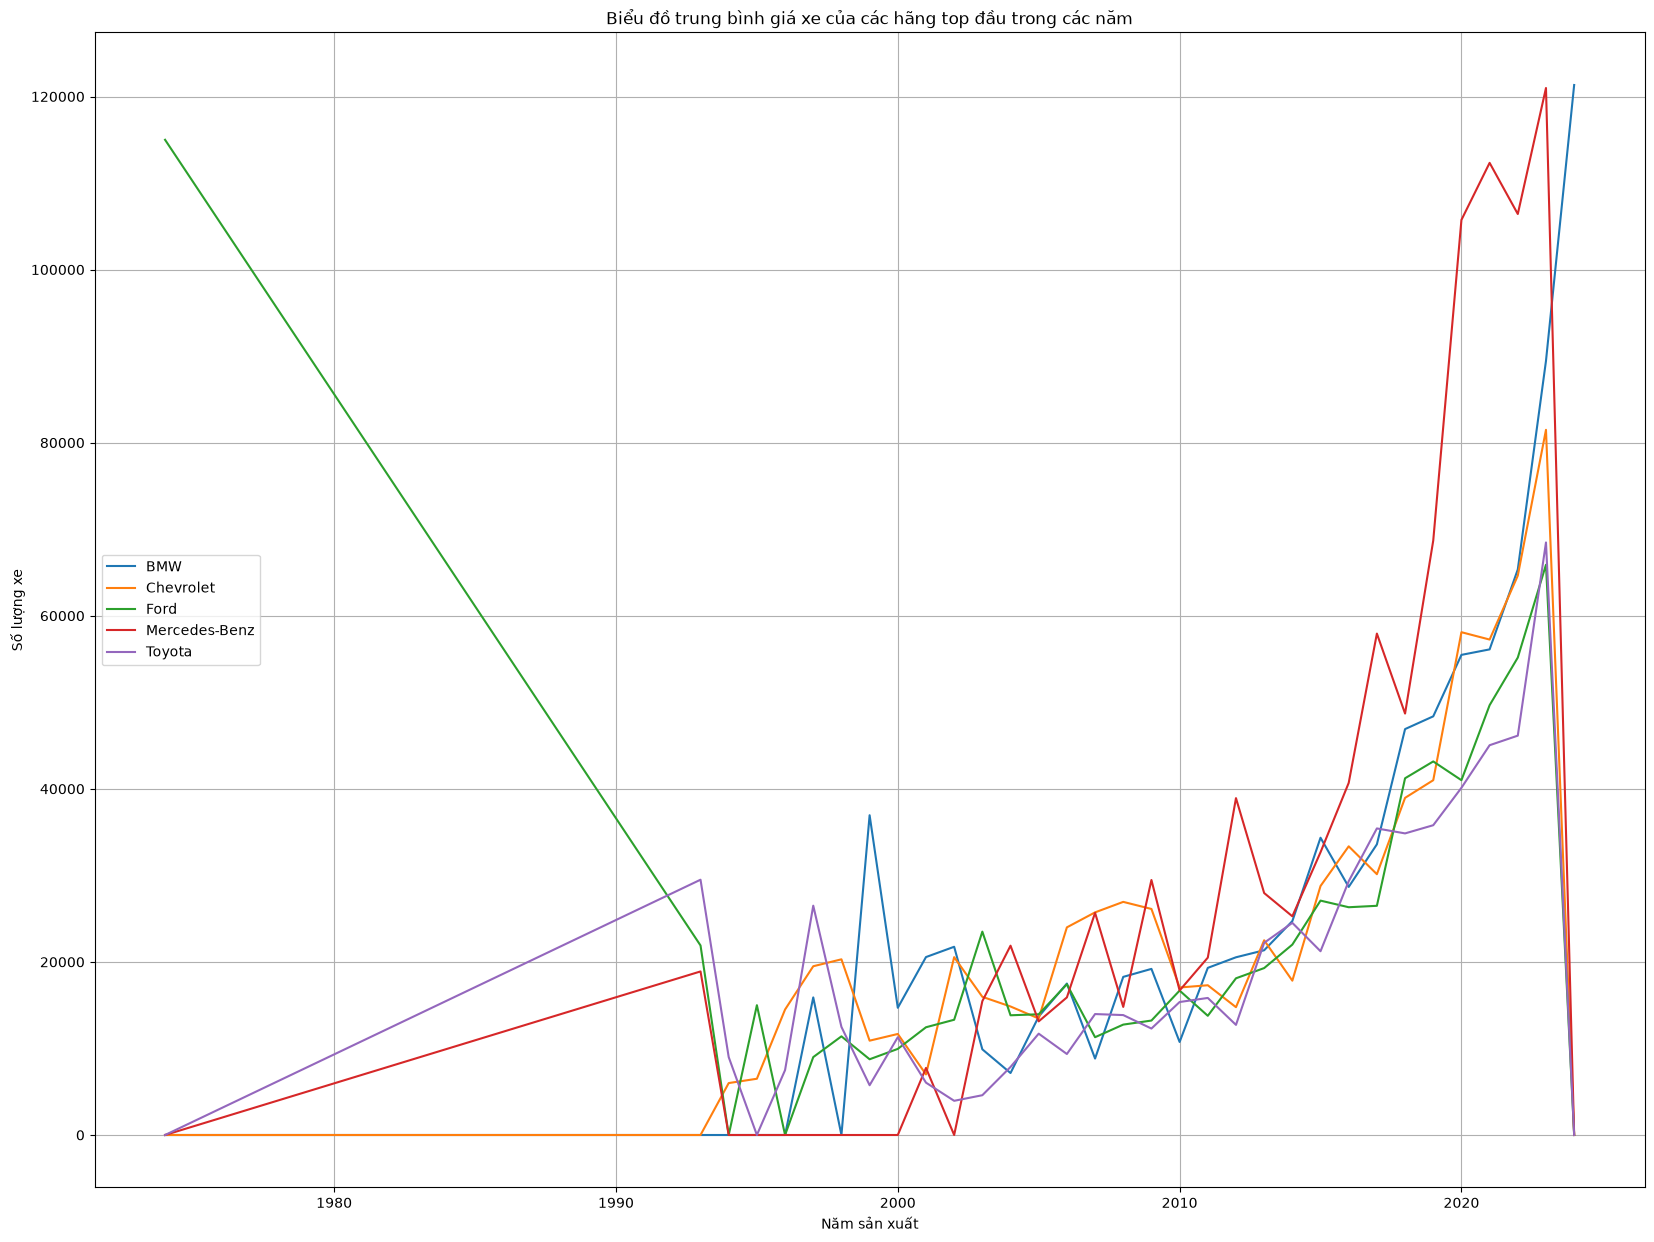

In [122]:
# Biều đồ đường: Biểu diễn trung bình giá xe của các hãng top đầu trong các năm

top_brand = df['brand'].value_counts().head().index

print(top_brand)
df_top_brand = df[df['brand'].isin(top_brand)]
pivot_df = df_top_brand.pivot_table(index='model_year', columns='brand', values='price', aggfunc='mean', fill_value=0)

plt.figure(figsize=(20, 15))
for brand in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[brand], label=brand)

plt.xlabel('Năm sản xuất')
plt.ylabel('Số lượng xe')
plt.legend()
plt.grid()
plt.title('Biểu đồ trung bình giá xe của các hãng top đầu trong các năm')

## Biểu đồ cột biểu diễn top 10 hãng xe có trung bình giá trị xe lớn nhất

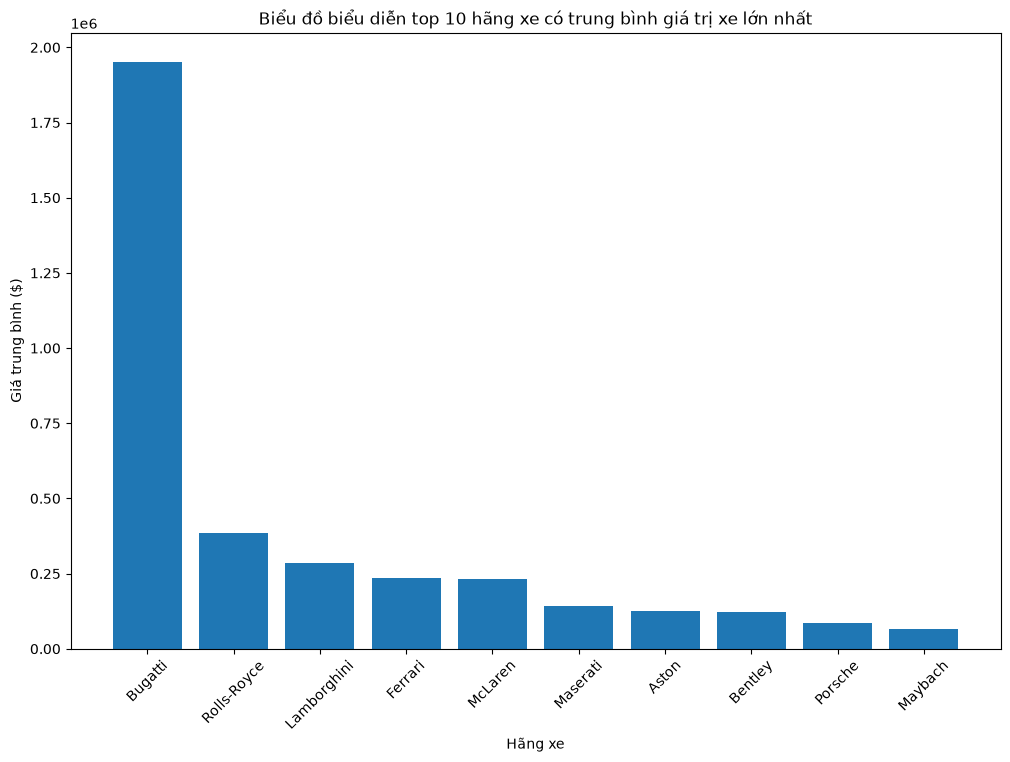

In [123]:
# Biểu đồ cột: Dùng để biểu diễn top 10 hãng xe có trung bình giá trị xe lớn nhất

df_sum_brand = df[['brand', 'price']].groupby('brand').mean()
df_sum_brand = df_sum_brand.sort_values(by='price', ascending=False).head(10)
df_sum_brand

plt.figure(figsize=(12, 8))
plt.bar(x=df_sum_brand.index, height=df_sum_brand['price'])
plt.xticks(rotation=45)
plt.title('Biểu đồ biểu diễn top 10 hãng xe có trung bình giá trị xe lớn nhất')
plt.xlabel('Hãng xe')
plt.ylabel('Giá trung bình ($)')
plt.show()


               count     avg_price
brand                             
Ford             341  33585.211144
BMW              316  37874.079114
Mercedes-Benz    268  50357.820896
Chevrolet        259  36273.382239
Toyota           171  28332.111111
Porsche          158  85909.183544
Audi             153  34116.372549
Lexus            136  32845.904412
Jeep             114  29110.868421
Land             100  49873.470000


C:\Users\thoma\AppData\Local\Temp\ipykernel_17492\4137910849.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(brand_stats.index, rotation=45, ha='right')


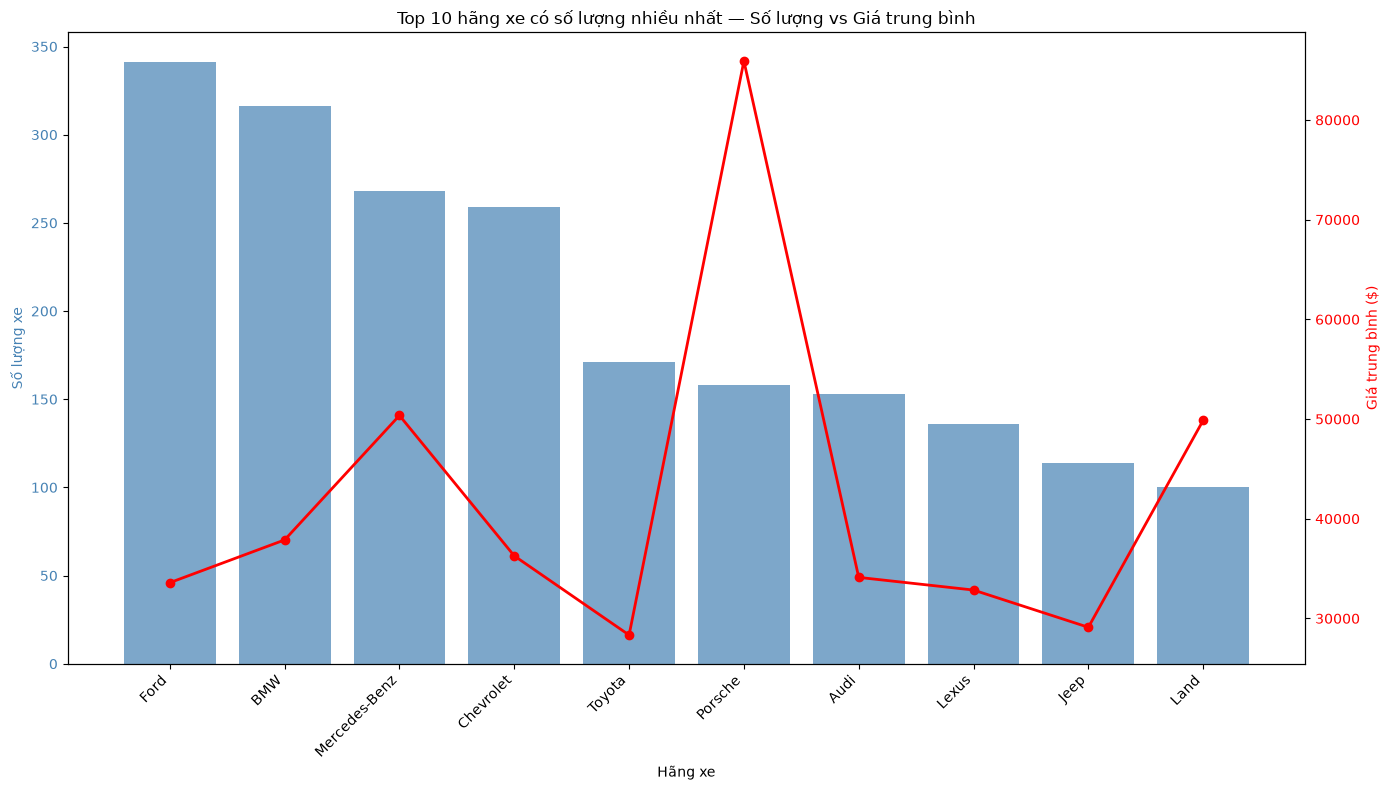

In [ ]:
# Biểu đồ đường và cột biểu diễn số lượng xe và giá trung bình của hãng đó


# Tính toán: đếm số lượng xe + giá trung bình theo hãng
brand_stats = df.groupby('brand').agg(
    count=('price', 'count'),
    avg_price=('price', 'mean')
).sort_values(by='count', ascending=False).head(10)

print(brand_stats)

# Vẽ biểu đồ kết hợp: Cột (số lượng) + Đường (giá trung bình)
fig, ax1 = plt.subplots(figsize=(14, 8))

# Trục trái: số lượng xe (cột)
color1 = 'steelblue'
ax1.bar(brand_stats.index, brand_stats['count'], color=color1, alpha=0.7, label='Số lượng xe')
ax1.set_xlabel('Hãng xe')
ax1.set_ylabel('Số lượng xe', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticklabels(brand_stats.index, rotation=45, ha='right')

# Trục phải: giá trung bình (đường)
ax2 = ax1.twinx()
color2 = 'red'
ax2.plot(brand_stats.index, brand_stats['avg_price'], color=color2, marker='o', linewidth=2, label='Giá trung bình')
ax2.set_ylabel('Giá trung bình ($)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Top 10 hãng xe có số lượng nhiều nhất — Số lượng vs Giá trung bình')
fig.tight_layout()
plt.show()

## Biểu đồ box plot biểu diễn giá trị ngoại lai

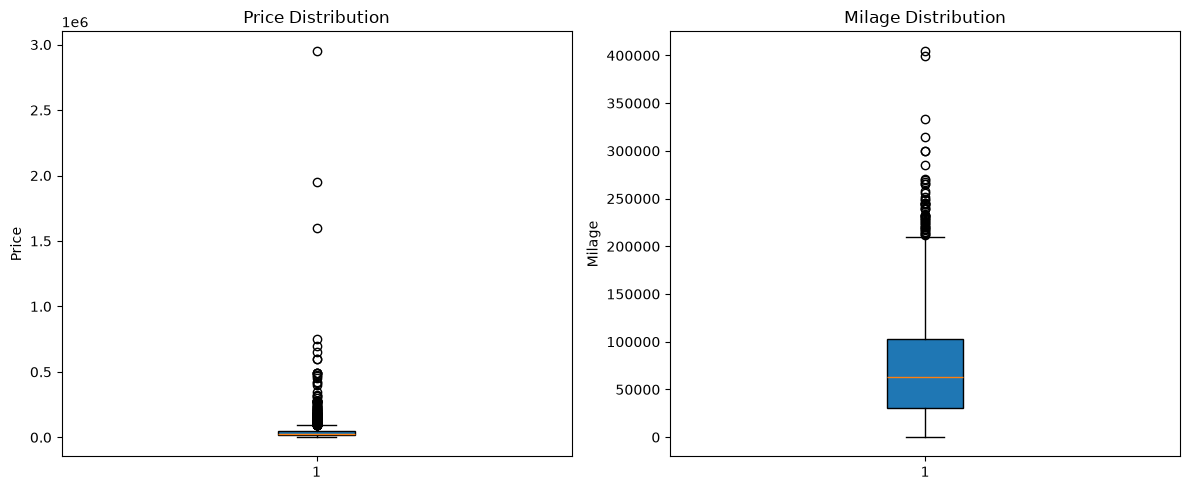

Q1=15500.0, Q3=46500.0, IQR=31000.0
Ngưỡng dưới=-31000.0, Ngưỡng trên=93000.0
Số outlier theo IQR: 185
Số dòng sau khi loại theo percentile 99: 3236


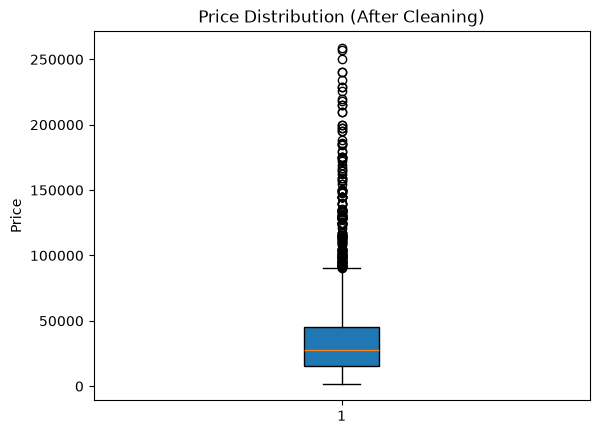

In [125]:
# Vẽ boxplot kiểm tra outlier
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(df['price'], patch_artist=True)
axes[0].set_title("Price Distribution")
axes[0].set_ylabel("Price")

axes[1].boxplot(df['milage'], patch_artist=True)
axes[1].set_title("Milage Distribution")
axes[1].set_ylabel("Milage")

plt.tight_layout()
plt.show()

# Tính ngưỡng outlier bằng IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}")
print(f"Ngưỡng dưới={lower_bound}, Ngưỡng trên={upper_bound}")
print("Số outlier theo IQR:", ((df['price'] < lower_bound) | (df['price'] > upper_bound)).sum())
q99 = df['price'].quantile(0.99)
df = df[df['price'] <= q99].reset_index(drop=True)
print("Số dòng sau khi loại theo percentile 99:", len(df))

# Vẽ lại boxplot sau khi làm sạch để kiểm tra
plt.boxplot(df['price'], patch_artist=True)
plt.title("Price Distribution (After Cleaning)")
plt.ylabel("Price")
plt.show()

## Biểu đồ quạt (pie chart) biểu diễn phần trăm các dữ liệu

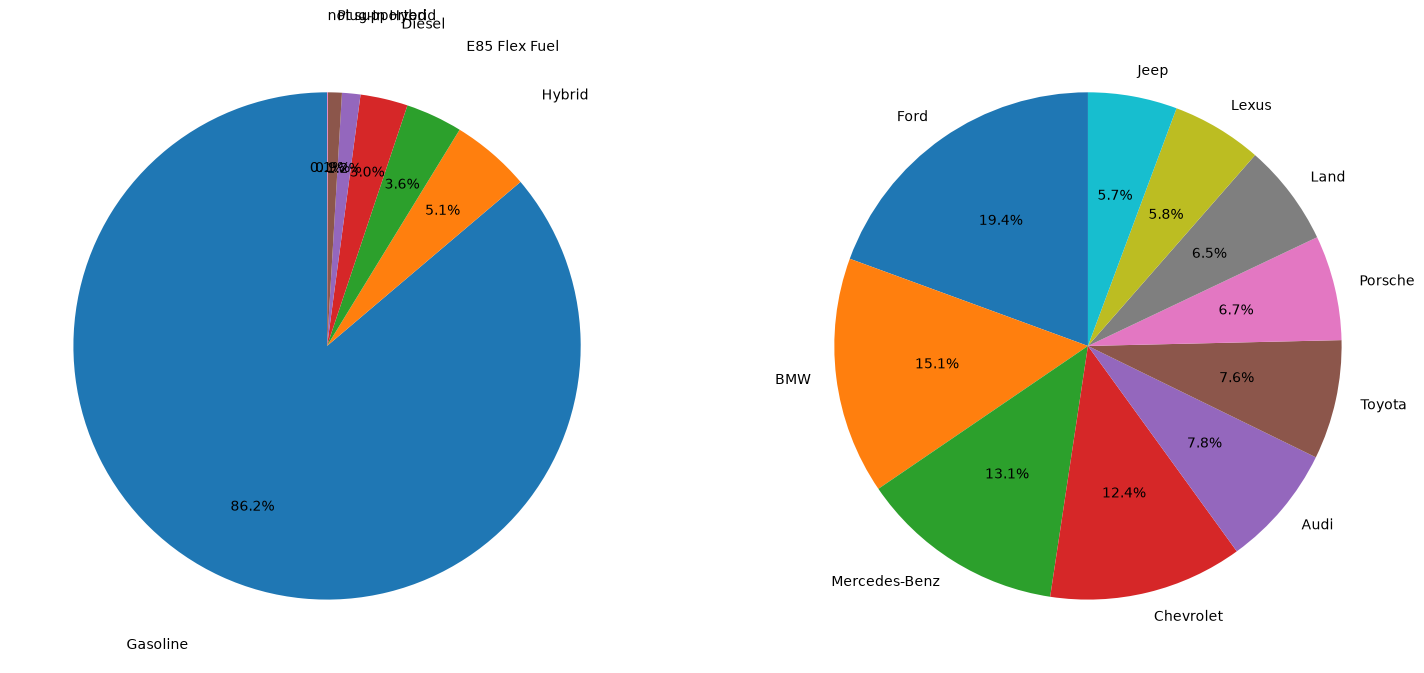

In [126]:
# Biểu đồ tròn biểu diễn phần trăm các dữ liệu

df_10years = df[df['model_year'] >= 2026 -10]
top_10_brand = df_10years['brand'].value_counts().head(10)

plt.figure(figsize=(18, 10))

# 1. Biều đồ tròn biểu diễn phần trăm các nhiên liệu của các hãng xe

plt.subplot(1, 2, 1)
plt.pie(fuel_counts, labels=fuel_counts.index, autopct='%1.1f%%', startangle=90, labeldistance=1.3, pctdistance=0.7)

# 2. Biều đồ tròn biểu diễn phần trăm tổng xe của top 10 hãng xe trong 10 năm gần nhất

plt.subplot(1, 2, 2)
plt.pie(top_10_brand, labels=top_10_brand.index, autopct='%1.1f%%', startangle=90)

plt.show()

In [127]:
df.head()

,brand,model,model_year,milage,fuel_type,transmission,ext_col,int_col,accident,clean_title,price,age,engine_hp,engine_liter,engine_cylinder
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,Automatic,Black,Black,at least 1 accident or damage reported,yes,10300,13,300.0,3.7,6.0
1,Hyundai,Palisade SEL,2021,34742,Gasoline,Automatic,Moonlight Cloud,Gray,at least 1 accident or damage reported,yes,38005,5,310.0,3.8,6.0
2,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,Automatic,Black,Black,none reported,yes,15500,11,354.0,3.5,6.0
3,Audi,S3 2.0T Premium Plus,2017,84000,Gasoline,Automatic,Blue,Black,none reported,yes,31000,9,292.0,2.0,4.0
4,BMW,740 iL,2001,242000,Gasoline,Automatic,Green,Green,none reported,yes,7300,25,282.0,4.4,8.0


In [128]:
MIN_COUNT = 10
model_counts = df['model'].value_counts()
rare_models = model_counts[model_counts < MIN_COUNT].index
df['model_grouped'] = df['model'].where(~df['model'].isin(rare_models), 'Other')

# Bỏ cột trùng lặp 
df = df.drop(columns=['model', 'model_year'])
df.head()

,brand,milage,fuel_type,transmission,ext_col,int_col,accident,clean_title,price,age,engine_hp,engine_liter,engine_cylinder,model_grouped
0,Ford,51000,E85 Flex Fuel,Automatic,Black,Black,at least 1 accident or damage reported,yes,10300,13,300.0,3.7,6.0,Other
1,Hyundai,34742,Gasoline,Automatic,Moonlight Cloud,Gray,at least 1 accident or damage reported,yes,38005,5,310.0,3.8,6.0,Other
2,INFINITI,88900,Hybrid,Automatic,Black,Black,none reported,yes,15500,11,354.0,3.5,6.0,Other
3,Audi,84000,Gasoline,Automatic,Blue,Black,none reported,yes,31000,9,292.0,2.0,4.0,Other
4,BMW,242000,Gasoline,Automatic,Green,Green,none reported,yes,7300,25,282.0,4.4,8.0,Other


# Chia tập dữ liệu để train và test và đánh giá kết quả dự đoán bằng các chỉ số

In [129]:
df.head()

# Tách X, y 
X = df.drop(columns=['price'])
y = np.log1p(df['price'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Target encoding cho model_grouped để fit trên train
tmp = X_train.copy()
tmp['price_log'] = y_train.values
model_target_map = tmp.groupby('model_grouped')['price_log'].mean()
global_mean = y_train.mean()

X_train['model_te'] = X_train['model_grouped'].map(model_target_map)
X_test['model_te']  = X_test['model_grouped'].map(model_target_map).fillna(global_mean)

X_train = X_train.drop(columns=['model_grouped'])
X_test  = X_test.drop(columns=['model_grouped'])

# Chuyển thành dạng one-hot encoding cho các categorical còn lại 
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test  = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

#  Scale numerical 
numerical_cols = ['age', 'milage', 'engine_hp', 'engine_liter',
                   'engine_cylinder', 'miles_per_year', 'model_te']
numerical_cols = [c for c in numerical_cols if c in X_train.columns]

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols]  = scaler.transform(X_test[numerical_cols])
print(X_train)
print("Số cột sau xử lý:", X_train.shape[1])

# Train model bằng Random Forest Regression 
model = RandomForestRegressor(n_estimators=100,random_state=42,)
model.fit(X_train, y_train)

y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test)

# Các chỉ số

mse = mean_squared_error(y_test_orig, y_pred)
mae = mean_absolute_error(y_test_orig, y_pred)
r2  = r2_score(y_test_orig, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("R2:", r2)

C:\Users\thoma\AppData\Local\Temp\ipykernel_17492\3828812415.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include='object').columns.tolist()


        milage       age  engine_hp  engine_liter  engine_cylinder  model_te  \
2933  0.306771 -0.242612  -0.979992     -1.227941        -1.419267 -0.098549   
1803  0.794647 -0.242612   0.901546      1.763772         1.120448 -0.098549   
1272 -0.885671 -0.890579  -0.133300     -1.584098        -0.149409 -0.098549   
761   1.681186 -0.242612   1.230816      1.763772         1.120448  1.862660   
2830  0.561347  0.405355  -0.086261      1.122691         1.120448 -0.098549   
...        ...       ...        ...           ...              ...       ...   
1095 -0.915963  1.539298  -0.133300     -0.373166        -0.149409 -0.098549   
1130 -1.101613 -0.242612   0.243008     -1.014247        -1.419267 -0.098549   
1294  0.337958 -0.404604   0.290046      1.122691         1.120448 -0.098549   
860   1.121266  1.701290  -0.283823      0.339147         1.120448 -0.098549   
3174  0.773351  0.405355  -1.281039     -1.512866        -1.419267 -0.098549   

      brand_Alfa  brand_Aston  brand_Au

# Biểu đồ biễu diễn độ chính xác của mô hình (Dự đoán và thực tế)

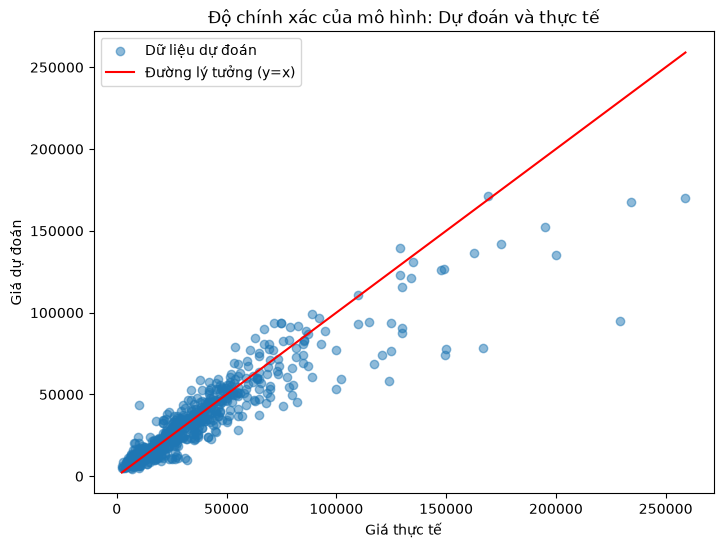

In [130]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_orig, y_pred, alpha=0.5, label='Dữ liệu dự đoán')

line_coords = [y_test_orig.min(), y_test_orig.max()]
plt.plot(line_coords, line_coords, color='red', label='Đường lý tưởng (y=x)')

plt.xlabel('Giá thực tế')
plt.ylabel('Giá dự đoán')
plt.title('Độ chính xác của mô hình: Dự đoán và thực tế')
plt.legend()
plt.show()

# Biểu diễn mức độ tương quan

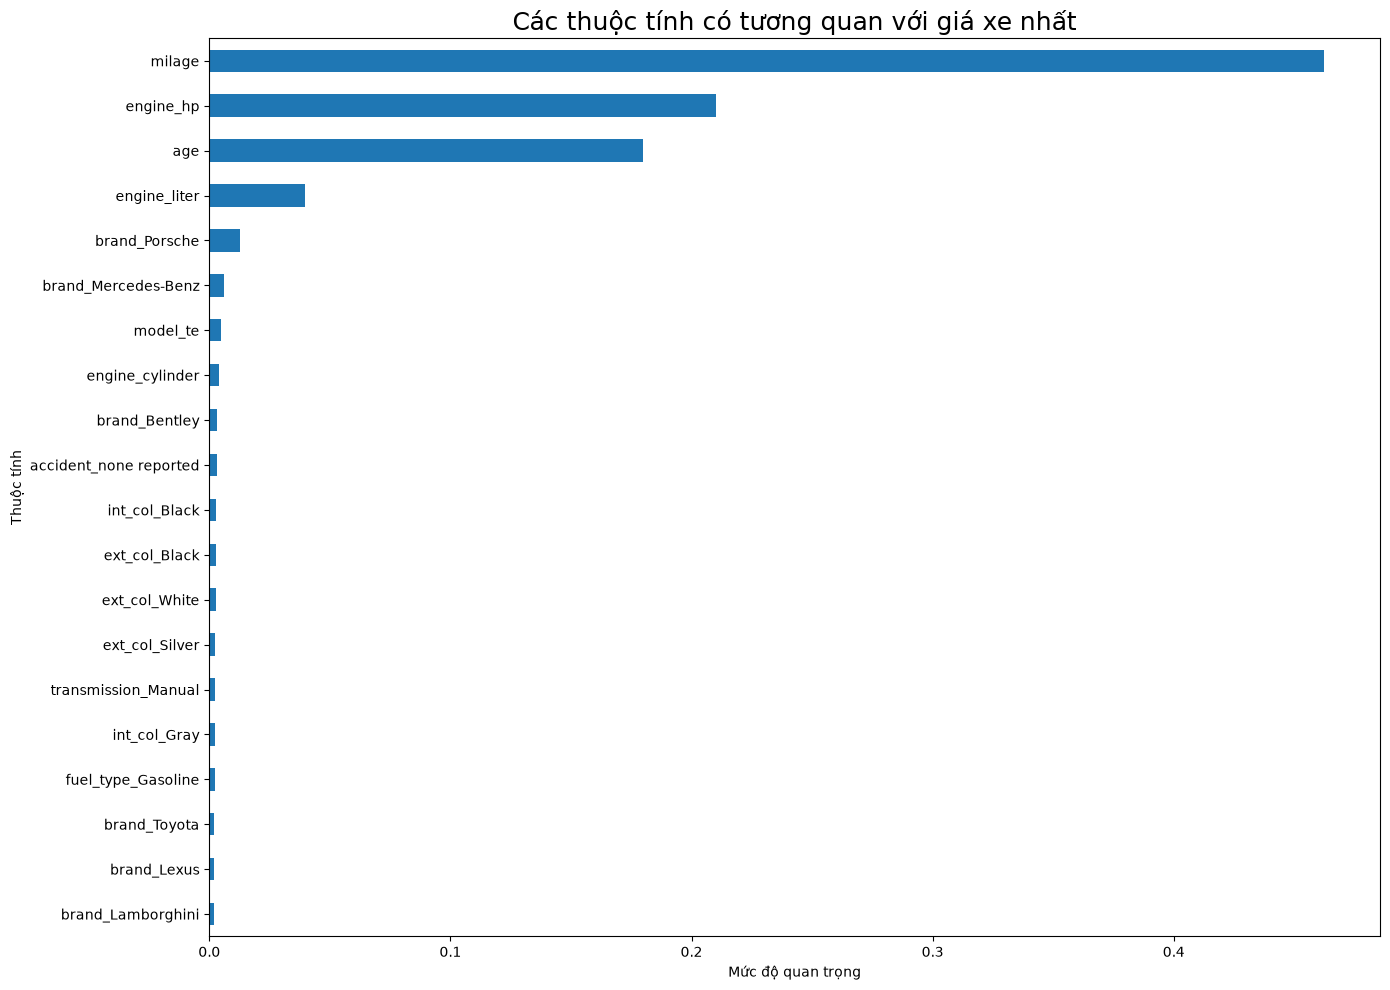

In [ ]:
# Sử dụng tính năng biểu diễn mức độ tương quan trong mô hình Random Forest Regression

importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(14, 10))

importance.head(20).sort_values().plot(
    kind='barh'
)

plt.title("Các thuộc tính có tương quan với giá xe nhất", fontsize=18)
plt.xlabel("Mức độ quan trọng")
plt.ylabel("Thuộc tính")

plt.tight_layout()
plt.show()
